In [2]:

install.packages(c("ggplot2", "ggrepel", "dplyr"))


Installing packages into ‘/home/khokholmongolll/R/x86_64-pc-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [ ]:
BiocManager::install("DESeq2")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org

Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29)

Installing package(s) 'DESeq2'

also installing the dependencies ‘RCurl’, ‘GenomeInfoDb’, ‘GenomicRanges’, ‘SummarizedExperiment’


Installation paths not writeable, unable to update packages
  path: /usr/lib/R/library
  packages:
    boot, class, cluster, codetools, foreign, KernSmooth, lattice, nlme, nnet,
    rpart, spatial, survival



Загрузим библиотеки и  данные

Loading required package: S4Vectors

Loading required package: stats4



Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loading required package: SummarizedExperiment

Loading required package: 

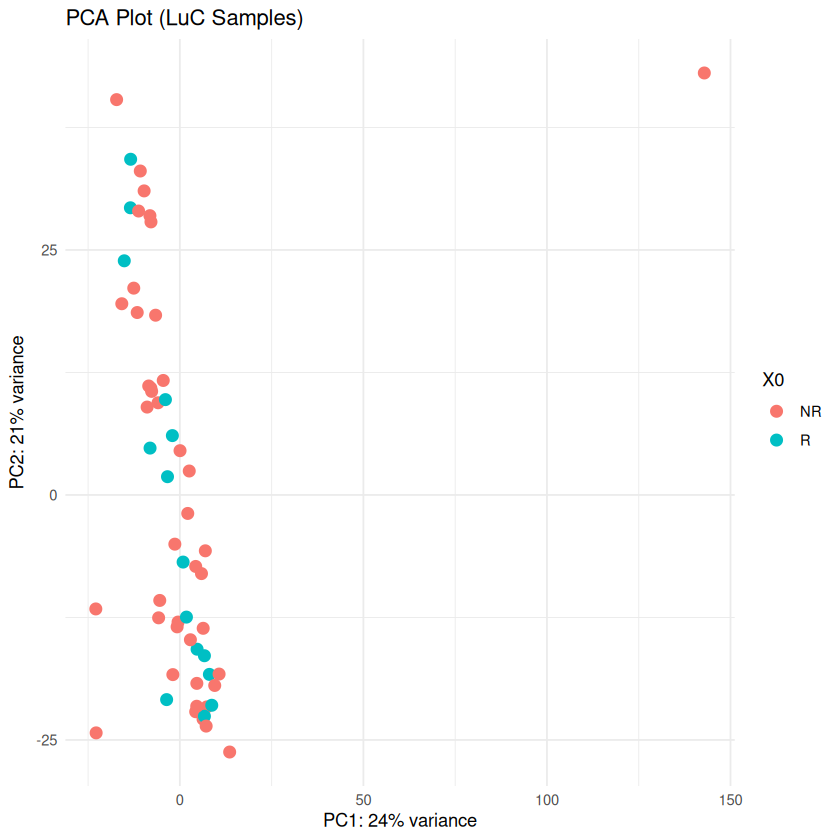

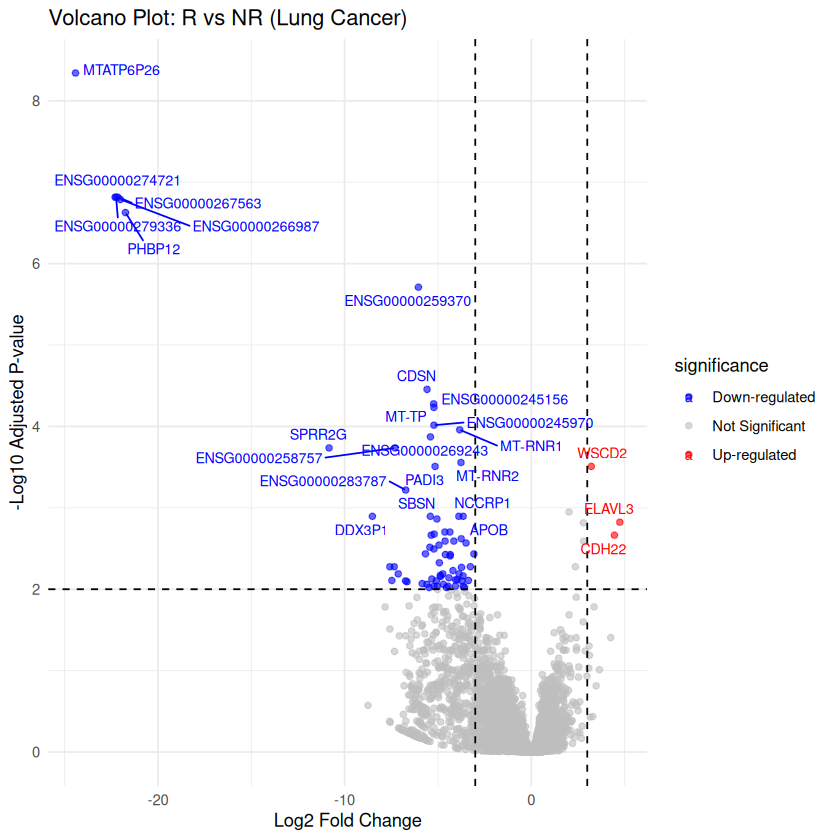

In [3]:

library(DESeq2)
library(ggplot2)
library(ggrepel)
library(dplyr)

counts <- read.csv("raw_counts_ici_samples.tsv", sep="\t", row.names=1, check.names=FALSE)
metadata <- read.csv("meta_responses.tsv", sep="\t", row.names=1)
hgnc <- read.csv("hgnc_complete_set.txt", sep="\t", row.names=1)

metadata <- metadata %>% filter(X0 %in% c('R', 'NR'))


common_samples <- intersect(colnames(counts), rownames(metadata))
counts <- counts[, common_samples]
metadata <- metadata[common_samples, , drop=FALSE]


metadata$X0 <- factor(metadata$X0, levels = c("NR", "R"))


dds <- DESeqDataSetFromMatrix(countData = round(counts),
                              colData = metadata,
                              design = ~ X0)

# 5. PCA (Анализ главных компонент)
vsd <- vst(dds, blind=FALSE)
pca_data <- plotPCA(vsd, intgroup="X0", returnData=TRUE)
percentVar <- round(100 * attr(pca_data, "percentVar"))

pca_plot <- ggplot(pca_data, aes(PC1, PC2, color=X0)) +
  geom_point(size=3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  ggtitle("PCA Plot (LuC Samples)") +
  theme_minimal()
print(pca_plot)

# 6. Запуск дифференциальной экспрессии
dds <- DESeq(dds)
res <- results(dds)

# 7. Аннотация (замена Ensembl ID на Gene Symbols)
symbol_map <- setNames(hgnc$symbol, hgnc$ensembl_gene_id)
res_df <- as.data.frame(res)
res_df$symbol <- symbol_map[rownames(res_df)]
res_df$symbol <- ifelse(is.na(res_df$symbol), rownames(res_df), res_df$symbol)

# 8. Определение значимых генов (padj < 0.01, |log2FC| > 3)
p_thresh <- 0.01
lfc_thresh <- 3

res_df <- res_df %>%
  mutate(significance = case_when(
    padj < p_thresh & log2FoldChange > lfc_thresh ~ "Up-regulated",
    padj < p_thresh & log2FoldChange < -lfc_thresh ~ "Down-regulated",
    TRUE ~ "Not Significant"
  ))

# 9. Построение Volcano Plot
volcano_plot <- ggplot(res_df, aes(x = log2FoldChange, y = -log10(padj), color = significance)) +
  geom_point(alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("Down-regulated" = "blue",
                                "Up-regulated" = "red",
                                "Not Significant" = "grey")) +
  geom_vline(xintercept = c(-lfc_thresh, lfc_thresh), linetype = "dashed") +
  geom_hline(yintercept = -log10(p_thresh), linetype = "dashed") +
  labs(title = "Volcano Plot: R vs NR (Lung Cancer)",
       x = "Log2 Fold Change",
       y = "-Log10 Adjusted P-value") +
  theme_minimal() +
  geom_text_repel(data = subset(res_df, significance != "Not Significant"),
                  aes(label = symbol), size = 3, max.overlaps = 15)
print(volcano_plot)

# 10. Сохранение результатов
write.csv(res_df, "DESeq2_full_results.csv")

In [ ]:
BiocManager::install("limma")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org

Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29)

Installing package(s) 'limma'

also installing the dependency ‘statmod’


Installation paths not writeable, unable to update packages
  path: /usr/lib/R/library
  packages:
    boot, class, cluster, codetools, foreign, KernSmooth, lattice, nlme, nnet,
    rpart, spatial, survival




Attaching package: ‘limma’


The following object is masked from ‘package:DESeq2’:

    plotMA


The following object is masked from ‘package:BiocGenerics’:

    plotMA




Количество значимых генов (P < 0.05):
|LogFC| > 1: 67 
|LogFC| > 2: 4 
|LogFC| > 3: 0 


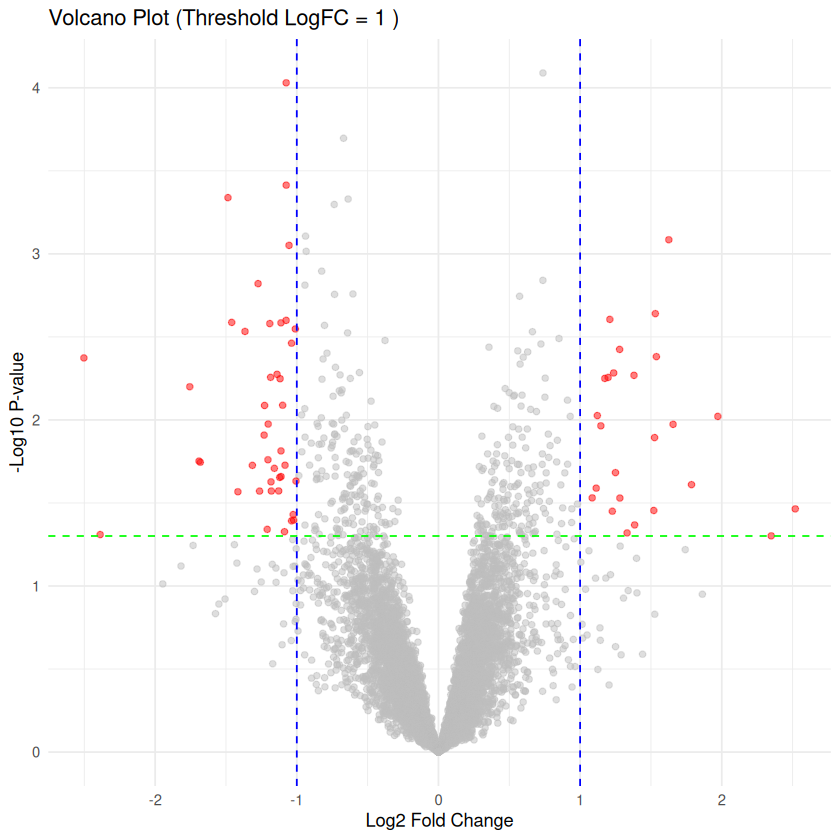

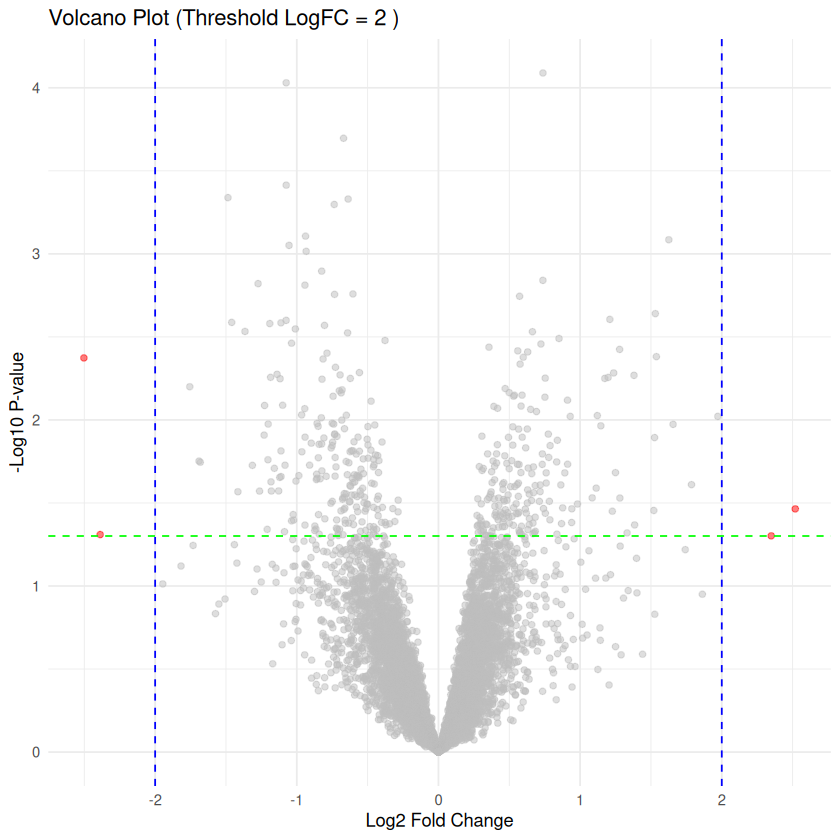

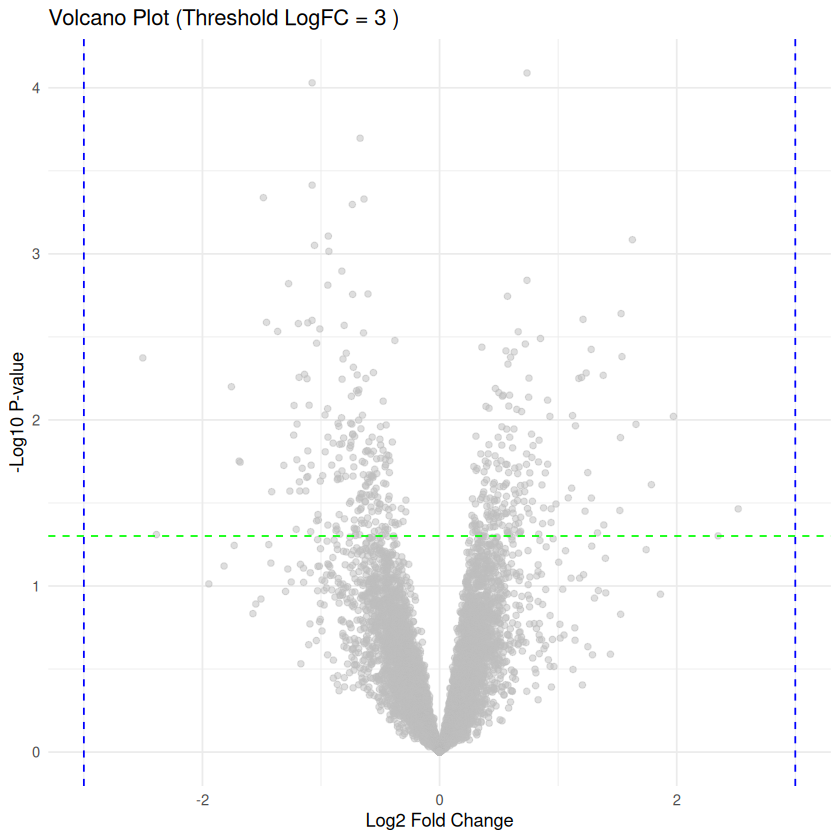

In [4]:
# 1. Загрузка библиотек
library(limma)
library(Biobase)
library(ggplot2)
library(dplyr)

# 2. Загрузка данных
# Пути к файлам (предполагается запуск из папки rna_seq_diff_exp)
exp_file <- "GSE63885/expression_for_limma2.csv"
ann_file <- "GSE63885/annotation_for_limma.csv"

exp_data <- read.csv(exp_file, row.names = "Gene.Symbol", header = TRUE)
ann_data <- read.csv(ann_file, row.names = 1, header = TRUE)

# 3. Подготовка объекта ExpressionSet
common_samples <- intersect(colnames(exp_data), rownames(ann_data))
exp_data <- as.matrix(exp_data[, common_samples])
ann_data <- ann_data[common_samples, ]

exp_set <- ExpressionSet(assayData = exp_data,
                         phenoData = AnnotatedDataFrame(ann_data))

# 4. Создание матрицы дизайна
# Статус ответа на химиотерапию (pCR vs pNC)
status_col <- "clinical.status.post.1st.line.chemotherapy..cr...complete.response..pr...partial.response..sd...stable.disease..p...progression..ch1"
group <- factor(ann_data[[status_col]], levels = c("pNC", "pCR"))

design <- model.matrix(~ group)
colnames(design) <- c("Intercept", "pCR_vs_pNC")

# 5. Линейное моделирование (LIMMA)
fit <- lmFit(exp_set, design)
fit <- eBayes(fit)


top_table <- topTable(fit, coef = "pCR_vs_pNC", adjust = "BH", n = Inf)


p_thresh <- 0.05

top_table <- top_table %>%
  mutate(
    sig_LFC1 = ifelse(P.Value < p_thresh & abs(logFC) > 1, "Significant", "Not Significant"),
    sig_LFC2 = ifelse(P.Value < p_thresh & abs(logFC) > 2, "Significant", "Not Significant"),
    sig_LFC3 = ifelse(P.Value < p_thresh & abs(logFC) > 3, "Significant", "Not Significant")
  )

# Вывод количества значимых генов в консоль
cat("Количество значимых генов (P < 0.05):\n")
cat("|LogFC| > 1:", sum(top_table$sig_LFC1 == "Significant"), "\n")
cat("|LogFC| > 2:", sum(top_table$sig_LFC2 == "Significant"), "\n")
cat("|LogFC| > 3:", sum(top_table$sig_LFC3 == "Significant"), "\n")

# 7. Функция для построения Volcano Plot
plot_volcano <- function(data, sig_column, lfc_val) {
  ggplot(data, aes(x = logFC, y = -log10(P.Value), color = .data[[sig_column]])) +
    geom_point(alpha = 0.5) +
    scale_color_manual(values = c("Significant" = "red", "Not Significant" = "grey")) +
    geom_vline(xintercept = c(-lfc_val, lfc_val), linetype = "dashed", color = "blue") +
    geom_hline(yintercept = -log10(p_thresh), linetype = "dashed", color = "green") +
    labs(title = paste("Volcano Plot (Threshold LogFC =", lfc_val, ")"),
         x = "Log2 Fold Change", y = "-Log10 P-value") +
    theme_minimal() +
    theme(legend.position = "none")
}

# Генерация графиков
p1 <- plot_volcano(top_table, "sig_LFC1", 1)
p2 <- plot_volcano(top_table, "sig_LFC2", 2)
p3 <- plot_volcano(top_table, "sig_LFC3", 3)

# Вывод графиков (в RStudio или PDF)
print(p1)
print(p2)
print(p3)

# 8. Сохранение результатов
write.csv(top_table, "LIMMA_results_final.csv")

In [5]:

sig_summary <- data.frame(
LogFC_Threshold = c(1, 2, 3),
Significant_Count = c(
sum(top_table$sig_LFC1 == "Significant"),
sum(top_table$sig_LFC2 == "Significant"),
sum(top_table$sig_LFC3 == "Significant")
)
)
print(sig_summary)
write.csv(sig_summary, "LIMMA_significance_summary.csv", row.names = FALSE)


  LogFC_Threshold Significant_Count
1               1                67
2               2                 4
3               3                 0


Количество значимых генов (FDR < 0.05):
|LogFC| > 1: 0 
|LogFC| > 2: 0 
|LogFC| > 3: 0 


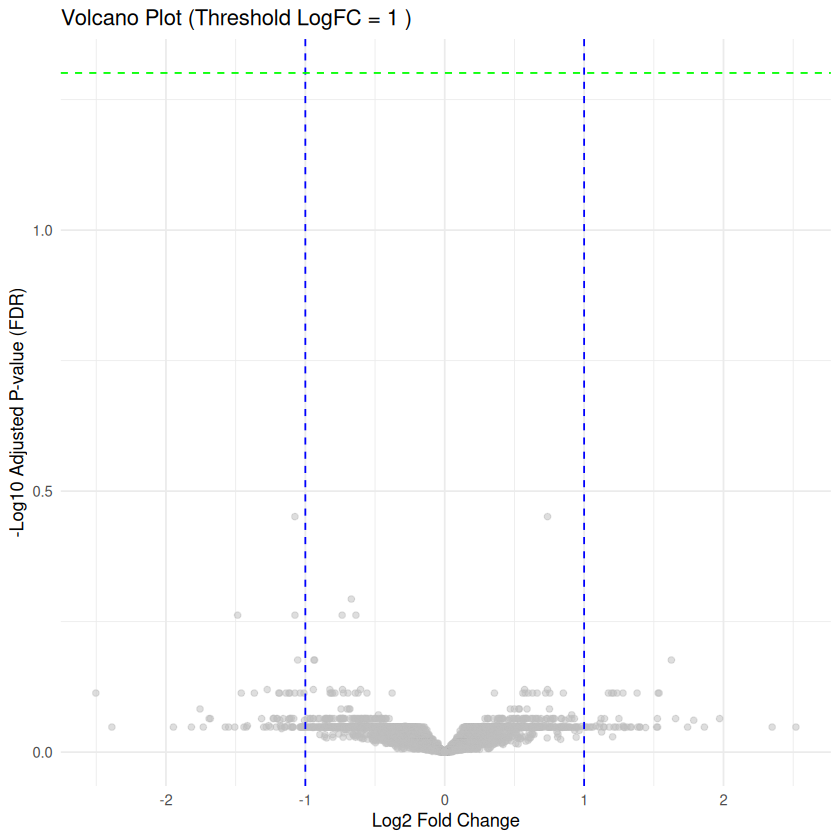

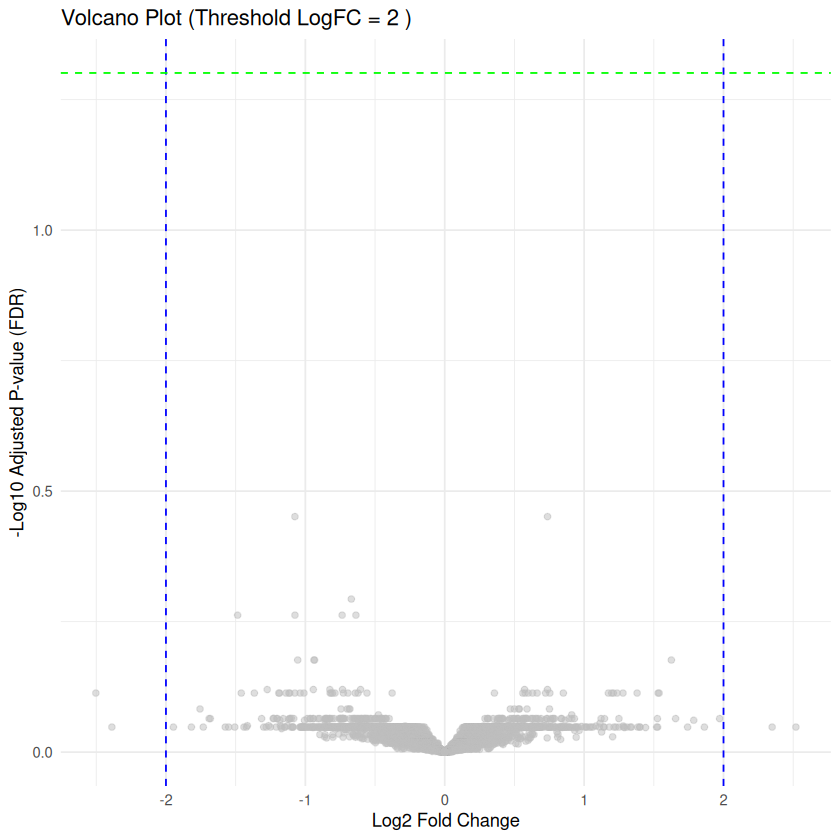

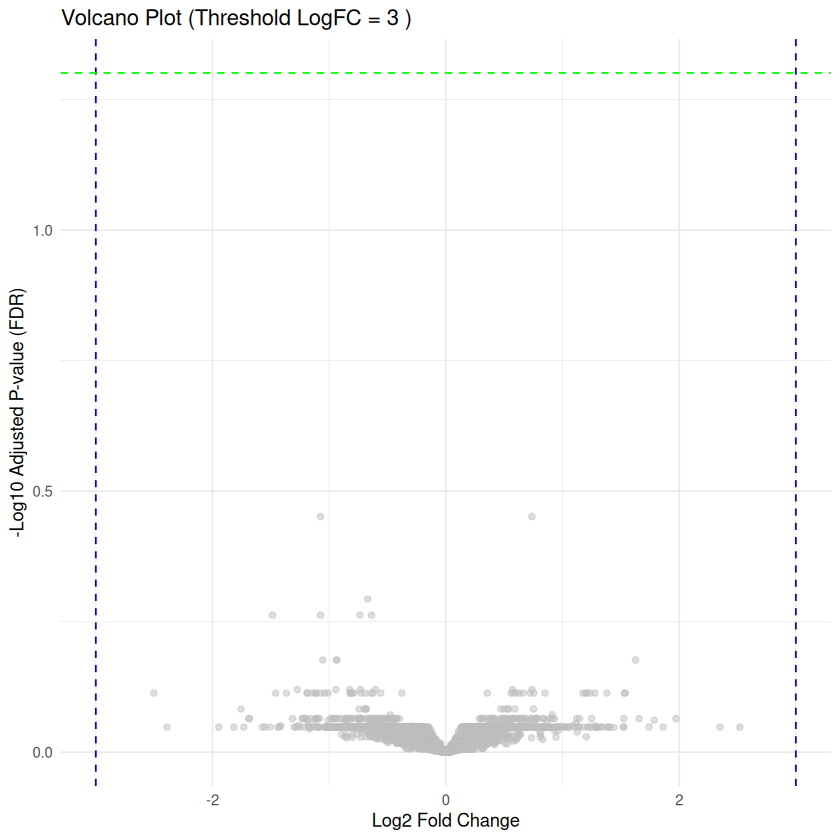

In [6]:
# 1. Загрузка библиотек
library(limma)
library(Biobase)
library(ggplot2)
library(dplyr)

# 2. Загрузка данных
# Пути к файлам (предполагается запуск из папки rna_seq_diff_exp)
exp_file <- "GSE63885/expression_for_limma2.csv"
ann_file <- "GSE63885/annotation_for_limma.csv"

exp_data <- read.csv(exp_file, row.names = "Gene.Symbol", header = TRUE)
ann_data <- read.csv(ann_file, row.names = 1, header = TRUE)

# 3. Подготовка объекта ExpressionSet
common_samples <- intersect(colnames(exp_data), rownames(ann_data))
exp_data <- as.matrix(exp_data[, common_samples])
ann_data <- ann_data[common_samples, ]

exp_set <- ExpressionSet(assayData = exp_data,
                         phenoData = AnnotatedDataFrame(ann_data))

# 4. Создание матрицы дизайна
# Статус ответа на химиотерапию (pCR vs pNC)
status_col <- "clinical.status.post.1st.line.chemotherapy..cr...complete.response..pr...partial.response..sd...stable.disease..p...progression..ch1"
group <- factor(ann_data[[status_col]], levels = c("pNC", "pCR"))

design <- model.matrix(~ group)
colnames(design) <- c("Intercept", "pCR_vs_pNC")

# 5. Линейное моделирование (LIMMA)
fit <- lmFit(exp_set, design)
fit <- eBayes(fit)


top_table <- topTable(fit, coef = "pCR_vs_pNC", adjust = "BH", n = Inf)


p_thresh <- 0.05 # Теперь это порог FDR

top_table <- top_table %>%
  mutate(
    sig_LFC1 = ifelse(adj.P.Val < p_thresh & abs(logFC) > 1, "Significant", "Not Significant"),
    sig_LFC2 = ifelse(adj.P.Val < p_thresh & abs(logFC) > 2, "Significant", "Not Significant"),
    sig_LFC3 = ifelse(adj.P.Val < p_thresh & abs(logFC) > 3, "Significant", "Not Significant")
  )

cat("Количество значимых генов (FDR < 0.05):\n")
cat("|LogFC| > 1:", sum(top_table$sig_LFC1 == "Significant"), "\n")
cat("|LogFC| > 2:", sum(top_table$sig_LFC2 == "Significant"), "\n")
cat("|LogFC| > 3:", sum(top_table$sig_LFC3 == "Significant"), "\n")


plot_volcano <- function(data, sig_column, lfc_val) {
  # Защита от нулей: заменяем 0 на 1e-300, чтобы -log10() не давал Inf
  data <- data %>% mutate(minus_log10_adjP = -log10(pmax(adj.P.Val, 1e-300)))
  
  ggplot(data, aes(x = logFC, y = minus_log10_adjP, color = .data[[sig_column]])) +
    geom_point(alpha = 0.5) +
    scale_color_manual(values = c("Significant" = "red", "Not Significant" = "grey")) +
    geom_vline(xintercept = c(-lfc_val, lfc_val), linetype = "dashed", color = "blue") +
    geom_hline(yintercept = -log10(p_thresh), linetype = "dashed", color = "green") +
    labs(title = paste("Volcano Plot (Threshold LogFC =", lfc_val, ")"),
         x = "Log2 Fold Change", y = "-Log10 Adjusted P-value (FDR)") +
    theme_minimal() +
    theme(legend.position = "none")
}

# Генерация графиков
p1 <- plot_volcano(top_table, "sig_LFC1", 1)
p2 <- plot_volcano(top_table, "sig_LFC2", 2)
p3 <- plot_volcano(top_table, "sig_LFC3", 3)

# Вывод графиков (в RStudio или PDF)
print(p1)
print(p2)
print(p3)

# 8. Сохранение результатов
write.csv(top_table, "LIMMA_results_final.csv")

In [ ]:
# Посмотрите распределение p-value
hist(top_table$adj.P.Val, breaks = 50, main = "Distribution of Adjusted P-values")

# Сколько генов с FDR < 0.1, 0.2, 0.5?
cat("FDR < 0.1:", sum(top_table$adj.P.Val < 0.1), "\n")
cat("FDR < 0.2:", sum(top_table$adj.P.Val < 0.2), "\n")
cat("FDR < 0.5:", sum(top_table$adj.P.Val < 0.5), "\n")

# Проверьте размеры групп
table(ann_data[[status_col]])

ERROR: Error: object 'top_table' not found
